# REACHER Data Pipeline Analysis

All alignment logic and visualization patterns are inlined so the notebook runs anywhere with `numpy`, `pandas`, `scipy`, `plotly`, `openpyxl`, and (optional) `ipywidgets`.

## What it does

1. Walks a dataset folder (e.g. `/mnt/external/JOSH/TDT4`) where each
   subfolder is one experimental condition containing one or more
   `*extractedsignals_raw.npy` signal files plus one REACHER-format `.xlsx`
   event log.
2. Loads each `.npy` as a separate `Sample`, all sharing the parsed event
   log and frame-timestamp grid (handles the *2-signals + 1-event-log*
   case, e.g. HI_D1's two FOVs).
3. Maps event timestamps (ms) to frame indices via `np.searchsorted` —
   verbatim port of Pynapse's algorithm.
4. Extracts `(trials, neurons, time)` peri-event windows around a
   user-selected event type, with optional buffer filtering, ΔF/F,
   z-scoring, and Gaussian smoothing.
5. Renders trial-mean ± SEM, sorted neuron heatmaps, and single-cell trial
   rasters using `plotly.graph_objects`.

## Read-only

The dataset on `/mnt/external/` is treated as read-only. The notebook
opens files for reading only; no temp files are placed in dataset folders.


In [ ]:
import warnings
from pathlib import Path
from typing import Iterable, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from numpy.typing import NDArray
from plotly.subplots import make_subplots
from scipy.ndimage import gaussian_filter1d

try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


In [ ]:
# REACHER event-code dictionary — verbatim copy of pynapse.config.events.REACHER.
# This is the one place the lab-standard mapping is defined; replicated here so
# the notebook has zero dependency on pynapse.
REACHER_EVENT_DICT: dict[int, str] = {
    # Right-hand lever
    101: "rh_lever_active_press",
    102: "rh_lever_timeout_press",
    103: "rh_lever_inactive_press",
    # Left-hand lever
    111: "lh_lever_active_press",
    112: "lh_lever_timeout_press",
    113: "lh_lever_inactive_press",
    # Drug delivery
    201: "pump_infusion",
    211: "pump_2_infusion",
    # Cue
    301: "cue_tone",
    311: "cue_2_tone",
    # Stimulation
    401: "laser_stim",
    # Licking
    501: "lick_lick",
    # Pavlovian trials
    601: "pavlov_trial_start",
    602: "pavlov_reward_delivered",
    603: "pavlov_reward_omitted",
    604: "pavlov_all_trials_complete",
    # Session control
    701: "controller_start",
    702: "controller_end",
}
_REACHER_LABEL_TO_CODE: dict[str, int] = {v: k for k, v in REACHER_EVENT_DICT.items()}

# Standard plotting colors — verbatim copy of pynapse.config.events.COLORS.
COLORS: dict[str, str] = {
    "active_lever_press": "#d32f2f",
    "active_lever_timeout": "#b71c1c",
    "inactive_lever_press": "#9e9e9e",
    "cue_onset": "#1976d2",
    "infusion": "#388e3c",
    "ethanol_delivery": "#7b1fa2",
    "water_delivery": "#0288d1",
    "frame_trigger": "#00000000",
    "rh_lever_active_press": "#d32f2f",
    "rh_lever_timeout_press": "#b71c1c",
    "rh_lever_inactive_press": "#9e9e9e",
    "lh_lever_active_press": "#ef5350",
    "lh_lever_timeout_press": "#c62828",
    "lh_lever_inactive_press": "#bdbdbd",
    "pump_infusion": "#388e3c",
    "pump_2_infusion": "#4caf50",
    "cue_tone": "#1976d2",
    "cue_2_tone": "#42a5f5",
    "laser_stim": "#7b1fa2",
    "lick_lick": "#ff9800",
    "pavlov_trial_start": "#00000000",
    "pavlov_reward_delivered": "#388e3c",
    "pavlov_reward_omitted": "#f44336",
    "pavlov_all_trials_complete": "#00000000",
    "controller_start": "#00000000",
    "controller_end": "#00000000",
}


def _hex_to_rgba(color: str, alpha: float = 1.0) -> str:
    """Convert ``#RRGGBB`` (or ``#RRGGBBAA``) to ``rgba(r,g,b,a)`` for Plotly."""
    if not color.startswith("#"):
        return color
    if len(color) == 7:
        r, g, b = int(color[1:3], 16), int(color[3:5], 16), int(color[5:7], 16)
        return f"rgba({r},{g},{b},{alpha})"
    if len(color) == 9:
        r = int(color[1:3], 16)
        g = int(color[3:5], 16)
        b = int(color[5:7], 16)
        a = round(int(color[7:9], 16) / 255 * alpha, 3)
        return f"rgba({r},{g},{b},{a})"
    return color


def event_color(label: str, alpha: float = 1.0) -> str:
    return _hex_to_rgba(COLORS.get(label, "#9e9e9e"), alpha=alpha)


In [ ]:
# Edit these values to point at a different dataset / change defaults.

DATASET_DIR: Path = Path("/mnt/external/JOSH/TDT4")

# Acquisition parameters (must match the recording).
FPS: float = 30.0
FRAME_AVERAGING: int = 4   # raw frames binned into one signal frame

# Default peri-event window.
PRE_S: float = 5.0
POST_S: float = 10.0
BUFFER_MS: int = 0
MIN_TRIALS: int = 3

# Default preprocessing pipeline (matches Axplorer defaults).
DFOF_PERCENTILE: float = 8.0
ZSCORE_WINDOW_MS: tuple[float, float] = (-3000.0, -500.0)
SMOOTHING_SIGMA: float = 2.0
ENABLE_DFOF: bool = True
ENABLE_ZSCORE: bool = True
ENABLE_SMOOTH: bool = True


## Loaders

The dataset organization assumed below mirrors the convention used by
`axplorer/api/state.py:_load_fov`:

```
DATASET_DIR/
├── HI_D1/                                # one folder per condition
│   ├── *_FOV1_*_extractedsignals_raw.npy
│   ├── *_FOV2_*_extractedsignals_raw.npy
│   └── TDT4_ESA_HIGHD1.xlsx              # one event log shared across FOVs
├── LOW_D1/
│   ├── *_FOV1_*_extractedsignals_raw.npy
│   └── TDT4_ESA_LOWD1.xlsx
└── ...
```

The xlsx is a REACHER-format export with sheets `Behavior Data` (events)
and `Frame Timestamps` (frame index → ms). When a folder has multiple
`.npy` files but one xlsx, each `.npy` becomes its own `Sample` and the
parsed event log + frame-timestamp grid are shared by reference. Frame
counts per `.npy` may differ from the xlsx's frame count; in that case a
warning is printed and out-of-bounds windows are dropped during tensor
extraction (matching Pynapse's behavior).


In [ ]:
def load_xlsx_events(
    xlsx_path: Path,
) -> Tuple[pd.DataFrame, Optional[NDArray[np.float64]]]:
    """Read a REACHER-format xlsx event log.

    Returns
    -------
    events_df : pd.DataFrame
        Columns: ``code`` (int), ``t1`` (start ms, float), ``t2`` (end ms,
        float, NaN if missing), ``label`` (str). Unknown ``device_event``
        composites are auto-assigned codes starting at 900 and a UserWarning
        is emitted — matches ``pynapse.core.io.behavior.EventLog._load_reacher_csv``.
    frame_ts_ms : NDArray[float64] or None
        Per-raw-frame timestamps in ms when the xlsx has a ``Frame
        Timestamps`` sheet; otherwise ``None`` and the caller will synthesize
        a regular grid.
    """
    xlsx_path = Path(xlsx_path)

    # ----- Behavior Data sheet -> events DataFrame -----
    beh = pd.read_excel(xlsx_path, sheet_name="Behavior Data", engine="openpyxl")
    expected = {"device", "event", "start_timestamp", "end_timestamp"}
    if not expected.issubset(beh.columns):
        raise ValueError(
            f"{xlsx_path.name} 'Behavior Data' sheet missing columns. "
            f"Expected superset of {expected}, got {set(beh.columns)}."
        )

    labels = (beh["device"].str.strip() + "_" + beh["event"].str.strip()).str.lower()

    next_auto_code = 900
    label_to_code = dict(_REACHER_LABEL_TO_CODE)
    for lbl in labels.unique():
        if lbl not in label_to_code:
            warnings.warn(
                f"Unknown REACHER event '{lbl}' in {xlsx_path.name} -- "
                f"auto-assigned code {next_auto_code}.",
                UserWarning,
                stacklevel=2,
            )
            label_to_code[lbl] = next_auto_code
            next_auto_code += 1

    codes = labels.map(label_to_code).astype(int).values
    t1 = beh["start_timestamp"].astype(float).values
    t2 = beh["end_timestamp"].astype(float).values
    code_to_label = {v: k for k, v in label_to_code.items()}
    events_df = pd.DataFrame({
        "code": codes,
        "t1": t1,
        "t2": t2,
        "label": [code_to_label.get(int(c), "unknown") for c in codes],
    })

    # ----- Frame Timestamps sheet -> ms array (optional) -----
    frame_ts_ms: Optional[NDArray[np.float64]] = None
    try:
        ft = pd.read_excel(xlsx_path, sheet_name="Frame Timestamps", engine="openpyxl")
        if ft.shape[1] >= 2:
            ts_col = ft.iloc[:, 1].astype(float).values
            frame_ts_ms = np.asarray(ts_col, dtype=np.float64)
    except Exception:
        # Sheet absent or unreadable -- caller will synthesize a regular grid.
        frame_ts_ms = None

    return events_df, frame_ts_ms


In [ ]:
class Sample:
    """Lightweight Pynapse-equivalent: events + signals + frame timestamps.

    The frame-timestamp / event-frame-index alignment is the same as
    ``pynapse.core.sample.Sample``: a per-RAW-frame timestamp array is
    averaged by ``frame_averaging`` (``full_ts[::frame_averaging]``), and
    event timestamps are mapped to frame indices with
    ``np.searchsorted(side="right") - 1``.

    Pass ``frame_ts_already_averaged=True`` when the input array is already
    one-entry-per-signal-frame (e.g. the REACHER xlsx 'Frame Timestamps'
    sheet). When ``frame_ts_ms`` is ``None`` a synthetic grid at the
    effective frame rate is used (matches Pynapse's fallback).
    """

    def __init__(
        self,
        events_df: pd.DataFrame,
        signals: NDArray[np.floating],
        frame_ts_ms: Optional[NDArray[np.float64]],
        fps: float,
        frame_averaging: int,
        name: str,
        frame_ts_already_averaged: bool = False,
    ) -> None:
        self.events_df = events_df  # shared by reference; never mutated
        self.signals = np.asarray(signals)
        if self.signals.ndim != 2:
            raise ValueError(f"signals must be 2-D (neurons, frames); got {self.signals.shape}")
        self.fps = float(fps)
        self.frame_averaging = int(frame_averaging)
        self.name = str(name)

        # Two input semantics for the timestamp array:
        #   frame_ts_already_averaged=False (Pynapse default): one entry per
        #     RAW frame; we apply ``full_ts[::frame_averaging]`` to derive
        #     the per-signal-frame grid -- identical to
        #     ``pynapse.core.sample.Sample._get_frame_timestamps``.
        #   frame_ts_already_averaged=True: the array already has one entry
        #     per signal frame (e.g. the REACHER xlsx 'Frame Timestamps'
        #     sheet). Used as-is.
        # If the resulting length disagrees with ``num_frames``, a warning
        # fires (matching Pynapse) and the bounds check in
        # ``extract_event_windows`` drops out-of-range trials.
        # Falls back to a synthetic grid when no array is supplied.
        if frame_ts_ms is not None and len(frame_ts_ms) > 0:
            arr = np.asarray(frame_ts_ms, dtype=np.float64)
            averaged = arr if frame_ts_already_averaged else arr[::self.frame_averaging]
        else:
            averaged = np.arange(self.num_frames) * self.frame_duration_ms

        if len(averaged) != self.num_frames:
            warnings.warn(
                f"{self.name}: signal frames ({self.num_frames}) != frame_ts "
                f"length ({len(averaged)}). Trimmed signals in this case.",
                UserWarning,
                stacklevel=2,
            )
        self.frame_ts_ms: NDArray[np.float64] = averaged

    # ------------------------------------------------------------------
    # Properties
    # ------------------------------------------------------------------
    @property
    def num_neurons(self) -> int:
        return int(self.signals.shape[0])

    @property
    def num_frames(self) -> int:
        return int(self.signals.shape[1])

    @property
    def num_events(self) -> int:
        return int(len(self.events_df))

    @property
    def effective_fps(self) -> float:
        return self.fps / self.frame_averaging

    @property
    def frame_duration_ms(self) -> float:
        return 1000.0 / self.effective_fps

    @property
    def interframe_interval(self) -> float:
        """Raw inter-frame interval in ms (before averaging)."""
        return 1000.0 / self.fps

    # ------------------------------------------------------------------
    # Event helpers
    # ------------------------------------------------------------------
    def get_dataframe(self) -> pd.DataFrame:
        """Return events with an added ``frame_index`` column (post-averaging).

        Identical algorithm to ``pynapse.core.sample.Sample.get_dataframe``:
        ``np.searchsorted(frame_ts, t1, side="right") - 1``, clipped to
        valid bounds.
        """
        df = self.events_df.copy()
        ts = df["t1"].astype(float).values
        idx = np.searchsorted(self.frame_ts_ms, ts, side="right") - 1
        idx = np.clip(idx, 0, max(len(self.frame_ts_ms) - 1, 0))
        df["frame_index"] = idx.astype(np.int64)
        return df

    def get_event_labels(self) -> List[str]:
        """Distinct event labels present in this sample, sorted, excluding common control codes."""
        labels = sorted(set(self.events_df["label"].astype(str)))
        return [
            l for l in labels
            if l not in {"frame_trigger", "controller_start", "controller_end",
                         "pavlov_trial_start", "pavlov_all_trials_complete", "unknown"}
        ]

    def get_event_timestamps(self, code: Union[int, Sequence[int]]) -> NDArray[np.float64]:
        codes = [code] if isinstance(code, (int, np.integer)) else list(code)
        mask = self.events_df["code"].isin(codes)
        return np.sort(self.events_df.loc[mask, "t1"].astype(float).values)

    def __repr__(self) -> str:
        return (
            f"Sample(name='{self.name}', neurons={self.num_neurons}, "
            f"frames={self.num_frames}, events={self.num_events})"
        )


In [ ]:
def load_fov_directory(
    fov_dir: Path,
    fps: float = FPS,
    frame_averaging: int = FRAME_AVERAGING,
) -> List[Sample]:
    """Load every ``*extractedsignals_raw.npy`` in ``fov_dir`` as its own Sample.

    All resulting Samples share the same parsed event DataFrame and
    raw frame-timestamp array (passed by reference; immutable downstream).

    Returns an empty list if no signals or no event log are present.
    """
    fov_dir = Path(fov_dir)
    npy_paths = sorted(fov_dir.glob("*extractedsignals_raw.npy"))
    xlsx_paths = sorted(fov_dir.glob("*.xlsx"))
    if not npy_paths or not xlsx_paths:
        return []
    if len(xlsx_paths) > 1:
        warnings.warn(
            f"{fov_dir.name}: {len(xlsx_paths)} xlsx files found; using {xlsx_paths[0].name}",
            UserWarning,
            stacklevel=2,
        )
    xlsx = xlsx_paths[0]

    events_df, frame_ts_xlsx = load_xlsx_events(xlsx)

    samples: List[Sample] = []
    for npy in npy_paths:
        signals = np.load(npy).squeeze()
        if signals.ndim == 1:
            signals = signals[np.newaxis, :]
        if signals.ndim != 2:
            warnings.warn(
                f"Skipping {npy.name}: unexpected signal shape {signals.shape}",
                UserWarning,
                stacklevel=2,
            )
            continue

        sample_name = f"{fov_dir.name}__{npy.stem}"
        # Decide whether to use the xlsx Frame Timestamps for this signal.
        # The sheet stores per-signal-frame timestamps; we accept it when
        # its length is within a small tolerance of this signal's frame
        # count. Otherwise (e.g. HI_D1's FOV2 which has a different frame
        # count from the shared event log) fall back to the synthetic grid.
        n_sig = signals.shape[1]
        if frame_ts_xlsx is not None and abs(len(frame_ts_xlsx) - n_sig) <= max(8, int(0.005 * n_sig)):
            ts_for_sample: Optional[NDArray[np.float64]] = frame_ts_xlsx
            already_averaged = True
        else:
            ts_for_sample = None
            already_averaged = False
        sample = Sample(
            events_df=events_df,
            signals=signals,
            frame_ts_ms=ts_for_sample,
            fps=fps,
            frame_averaging=frame_averaging,
            name=sample_name,
            frame_ts_already_averaged=already_averaged,
        )
        samples.append(sample)

    return samples


In [ ]:
def load_dataset(root: Path) -> dict[str, list[Sample]]:
    """Walk ``root`` and load every immediate subdirectory as a group."""
    root = Path(root)
    if not root.is_dir():
        raise FileNotFoundError(f"DATASET_DIR does not exist: {root}")

    groups: dict[str, list[Sample]] = {}
    for sub in sorted(root.iterdir()):
        if not sub.is_dir() or sub.name.startswith(".") or sub.name == "logs":
            continue
        samples = load_fov_directory(sub)
        if samples:
            groups[sub.name] = samples
    return groups


SAMPLES_BY_GROUP: dict[str, list[Sample]] = load_dataset(DATASET_DIR)

# Print a summary table.
def _summarize(groups: dict[str, list[Sample]]) -> pd.DataFrame:
    rows = []
    for grp, samples in groups.items():
        for s in samples:
            rows.append({
                "group": grp,
                "sample": s.name,
                "neurons": s.num_neurons,
                "frames": s.num_frames,
                "events": s.num_events,
                "duration_s": round(s.num_frames / s.effective_fps, 1),
            })
    return pd.DataFrame(rows)


_summary_df = _summarize(SAMPLES_BY_GROUP)
print(f"Loaded {len(SAMPLES_BY_GROUP)} group(s), "
      f"{sum(len(v) for v in SAMPLES_BY_GROUP.values())} sample(s) total.")
_summary_df


/tmp/ipykernel_344481/2087051593.py:26: UserWarning: Unknown REACHER event 'lick_circuit_lick' in TDT4_ESA_HIGHD1.xlsx -- auto-assigned code 900.
  events_df, frame_ts_xlsx = load_xlsx_events(xlsx)
/tmp/ipykernel_344481/2087051593.py:26: UserWarning: Unknown REACHER event 'lick_circuit_lick' in TDT4_ESA_LOWD1.xlsx -- auto-assigned code 900.
  events_df, frame_ts_xlsx = load_xlsx_events(xlsx)
/tmp/ipykernel_344481/2087051593.py:26: UserWarning: Unknown REACHER event 'lick_circuit_lick' in TDT4_ESA_MIDD1.xlsx -- auto-assigned code 900.
  events_df, frame_ts_xlsx = load_xlsx_events(xlsx)


Loaded 4 group(s), 5 sample(s) total.


/tmp/ipykernel_344481/2087051593.py:54: UserWarning: MID_D1__040326_TDT4_MIDD1_ENSURESA_FOV1_BEH-003_extractedsignals_raw: signal frames (26887) != frame_ts length (26889). Trimmed signals in this case.
  sample = Sample(
/tmp/ipykernel_344481/2087051593.py:26: UserWarning: Unknown REACHER event 'lick_circuit_lick' in TDT4_ESA_MIDD2.xlsx -- auto-assigned code 900.
  events_df, frame_ts_xlsx = load_xlsx_events(xlsx)
/tmp/ipykernel_344481/2087051593.py:54: UserWarning: MID_D2__040626_TDT4_MIDD2_ENSURESA_FOV2_BEH-003_extractedsignals_raw: signal frames (17160) != frame_ts length (17155). Trimmed signals in this case.
  sample = Sample(


,group,sample,neurons,frames,events,duration_s
0,HI_D1,HI_D1__040126_TDT4_HIGHD1_ENSURESA_FOV1_BEH-00...,81,9755,200,1300.7
1,HI_D1,HI_D1__040126_TDT4_HIGHD1_ENSURESA_FOV2_BEH-00...,88,26887,200,3584.9
2,LOW_D1,LOW_D1__040726_TDT4_LOWD1_ENSURESA_FOV1_BEH-00...,92,26887,482,3584.9
3,MID_D1,MID_D1__040326_TDT4_MIDD1_ENSURESA_FOV1_BEH-00...,113,26887,355,3584.9
4,MID_D2,MID_D2__040626_TDT4_MIDD2_ENSURESA_FOV2_BEH-00...,96,17160,162,2288.0


## Alignment math (replicated from Pynapse)

Given a `Sample`, an `event_id`, and a window `(pre_s, post_s)`:

1. Collect all event timestamps (`t1`, in ms) where `code == event_id` (or
   any of a list of ids) and sort ascending.
2. **Buffer filter** — if `buffer_ms > 0`, drop the *later* of any pair of
   events whose start times are within `buffer_ms` of each other. (Same
   policy as Pynapse: keep the earliest event in each close cluster.)
3. **Frame-index lookup** — for each remaining event timestamp, find the
   signal frame whose timestamp is the largest `<=` the event time using
   `np.searchsorted(frame_ts, ts, side="right") - 1`. `frame_ts` here is
   the **post-averaging** grid (`raw_ts[::frame_averaging]`).
4. **Slice** — for each event-frame `idx`, extract signals
   `[:, idx - pre_frames : idx + post_frames]`. Drop windows that fall
   outside the signal bounds.
5. Stack to `(trials, neurons, time)`.

Optional preprocessing: a *trace pipeline* runs on the full `(neurons,
time)` array before slicing (e.g. ΔF/F on the whole session); a *window
pipeline* runs on the stacked `(trials, neurons, time)` tensor (e.g.
z-scoring with a pre-event baseline window, smoothing).

This is identical line-for-line in algorithm to
`pynapse/analysis/peri_event.py:SampleEventTensor._extract_event_windows`.


In [ ]:
class DFOverF:
    """ΔF/F using a percentile baseline along the last (time) axis.

    Verbatim port of ``pynapse.analysis.preprocessing.epoch.relative_change.DFOverF``.
    Works on 2-D ``(neurons, time)`` and 3-D ``(trials, neurons, time)`` arrays.
    """

    def __init__(self, percentile: float = 8.0):
        if not 0 <= percentile <= 100:
            raise ValueError("percentile must be in [0, 100]")
        self.percentile = float(percentile)

    def apply(self, signals: NDArray[np.floating]) -> NDArray[np.float32]:
        signals = np.asarray(signals, dtype=np.float64)
        if signals.ndim not in (2, 3):
            raise ValueError(f"Expected 2D or 3D array, got {signals.ndim}D")
        F0 = np.percentile(signals, self.percentile, axis=-1, keepdims=True)
        F0_safe = np.where(F0 == 0, np.nan, F0)
        return ((signals - F0_safe) / F0_safe).astype(np.float32)

    __call__ = apply


class ZScore:
    """Z-score using a baseline window in ms relative to event onset.

    Verbatim port of ``pynapse.analysis.preprocessing.epoch.standardization.ZScore``.
    """

    def __init__(
        self,
        window_ms: tuple[float, float] = (-3000.0, -500.0),
        frame_duration_ms: float = 133.333,
        full_trace: bool = False,
    ):
        self.window_ms = (float(window_ms[0]), float(window_ms[1]))
        self.frame_duration_ms = float(frame_duration_ms)
        self.full_trace = bool(full_trace)

    def apply(self, signals: NDArray[np.floating]) -> NDArray[np.float32]:
        signals = np.asarray(signals, dtype=np.float64)
        if signals.ndim not in (2, 3):
            raise ValueError(f"Expected 2D or 3D array, got {signals.ndim}D")
        if self.full_trace:
            means = np.nanmean(signals, axis=-1, keepdims=True)
            stds = np.nanstd(signals, axis=-1, keepdims=True)
        else:
            if signals.ndim == 2:
                start = max(0, int(self.window_ms[0] / self.frame_duration_ms))
                end = min(int(self.window_ms[1] / self.frame_duration_ms), signals.shape[-1])
                baseline = signals[:, start:end]
            else:
                # For 3-D windows the time axis is centered on the event;
                # absolute frame indices map: 0 = event onset.
                start, end = 0, signals.shape[-1]
                baseline = signals[..., start:end]
            means = np.nanmean(baseline, axis=-1, keepdims=True)
            stds = np.nanstd(baseline, axis=-1, keepdims=True)
        stds = np.where(stds == 0, 1.0, stds)
        return ((signals - means) / stds).astype(np.float32)

    __call__ = apply


class GaussianSmoothing:
    """1-D Gaussian smoothing along the time axis.

    Verbatim port of ``pynapse.analysis.preprocessing.epoch.gaussian_smoothing.GaussianSmoothing``.
    """

    def __init__(self, sigma_frames: float = 2.0):
        if sigma_frames <= 0:
            raise ValueError("sigma_frames must be > 0")
        self.sigma_frames = float(sigma_frames)

    def apply(self, signals: NDArray[np.floating]) -> NDArray[np.float32]:
        signals = np.asarray(signals)
        if signals.ndim not in (2, 3):
            raise ValueError(f"Expected 2D or 3D array, got {signals.ndim}D")
        return gaussian_filter1d(signals, sigma=self.sigma_frames, axis=-1).astype(np.float32)

    __call__ = apply


class Pipeline:
    """Apply a sequence of preprocessors in order."""

    def __init__(self, steps: Sequence[object]):
        self.steps = list(steps)

    def apply(self, signals: NDArray[np.floating]) -> NDArray[np.floating]:
        out = signals
        for step in self.steps:
            out = step.apply(out)
        return out

    __call__ = apply


def build_default_pipeline(
    effective_fps: float,
    dfof_pct: float = DFOF_PERCENTILE,
    zscore_window_ms: tuple[float, float] = ZSCORE_WINDOW_MS,
    smoothing_sigma: float = SMOOTHING_SIGMA,
    enable_dfof: bool = ENABLE_DFOF,
    enable_zscore: bool = ENABLE_ZSCORE,
    enable_smooth: bool = ENABLE_SMOOTH,
) -> Optional[Pipeline]:
    """Construct the Axplorer-equivalent 3-step preprocessing pipeline."""
    steps: list[object] = []
    if enable_dfof:
        steps.append(DFOverF(percentile=dfof_pct))
    if enable_zscore:
        frame_dur_ms = 1000.0 / effective_fps
        steps.append(ZScore(window_ms=zscore_window_ms, frame_duration_ms=frame_dur_ms))
    if enable_smooth:
        steps.append(GaussianSmoothing(sigma_frames=smoothing_sigma))
    return Pipeline(steps) if steps else None


In [ ]:
def make_time_axis(pre_s: float, post_s: float, fps_eff: float) -> NDArray[np.float64]:
    """Time axis from -pre to +post at ``1/fps_eff`` spacing."""
    n = int(round((pre_s + post_s) * fps_eff))
    if n <= 0:
        return np.array([], dtype=np.float64)
    return np.linspace(-pre_s, post_s, n, endpoint=False)


def extract_event_windows(
    sample: Sample,
    event_id: Union[int, Sequence[int]],
    pre_s: float,
    post_s: float,
    buffer_ms: int = 0,
    min_trials: int = 1,
    trace_pipeline: Optional[Pipeline] = None,
    window_pipeline: Optional[Pipeline] = None,
) -> Tuple[NDArray[np.float32], NDArray[np.float64]]:
    """Extract a (trials, neurons, time) peri-event tensor from ``sample``.

    Returns
    -------
    windows : NDArray[float32], shape (n_trials, n_neurons, n_time)
        Empty along the trial axis if no events qualify.
    time_axis : NDArray[float64]
        Length ``n_time``; ``0`` corresponds to event onset.
    """
    df = sample.get_dataframe()
    signals = sample.signals
    if trace_pipeline is not None:
        signals = trace_pipeline.apply(signals)

    fps_eff = sample.effective_fps
    event_ids = list(event_id) if isinstance(event_id, (list, tuple)) else [event_id]

    parts = [df.loc[df["code"] == int(eid), "t1"].astype(float).values for eid in event_ids]
    event_ts_ms = (
        np.sort(np.concatenate(parts).astype(np.float64))
        if any(len(p) for p in parts) else np.array([], dtype=np.float64)
    )

    # Buffer filter: keep earliest in each close pair (Pynapse policy).
    if buffer_ms > 0 and event_ts_ms.size > 1:
        diffs = np.diff(event_ts_ms)
        close_idx = np.where(diffs < buffer_ms)[0] + 1
        event_ts_ms = np.delete(event_ts_ms, close_idx)

    pre_frames = int(pre_s * fps_eff)
    post_frames = int(post_s * fps_eff)
    window_size = pre_frames + post_frames
    time_axis = make_time_axis(pre_s, post_s, fps_eff)

    if event_ts_ms.size < min_trials:
        return np.empty((0, sample.num_neurons, window_size), dtype=np.float32), time_axis

    frame_ts = sample.frame_ts_ms
    if len(frame_ts) == 0:
        return np.empty((0, sample.num_neurons, window_size), dtype=np.float32), time_axis

    indices = np.searchsorted(frame_ts, event_ts_ms, side="right") - 1
    indices = np.clip(indices, 0, len(frame_ts) - 1)
    valid = frame_ts[indices] <= event_ts_ms
    indices[~valid] = 0  # mark for skip-via-zero (matches pynapse)

    windows: list[NDArray] = []
    for idx in indices:
        if idx == 0:  # the sentinel for invalid/before-first-frame
            continue
        start, end = idx - pre_frames, idx + post_frames
        if start < 0 or end > signals.shape[1]:
            continue
        windows.append(signals[:, start:end])

    if not windows:
        return np.empty((0, sample.num_neurons, window_size), dtype=np.float32), time_axis

    stacked = np.stack(windows, axis=0).astype(np.float32)
    if window_pipeline is not None:
        stacked = window_pipeline.apply(stacked)
    return stacked, time_axis


def trial_mean_sem(
    windows: NDArray[np.floating],
) -> Tuple[NDArray[np.float32], NDArray[np.float32]]:
    """Mean and SEM along the trial axis (axis 0). Same as Axplorer's compute_peth."""
    if windows.ndim != 3 or windows.shape[0] == 0:
        empty = np.zeros((windows.shape[1], windows.shape[2]) if windows.ndim == 3
                         else (0, 0), dtype=np.float32)
        return empty, empty.copy()
    n_trials = windows.shape[0]
    mean = np.nanmean(windows, axis=0).astype(np.float32)
    sem = (np.nanstd(windows, axis=0, ddof=1) / np.sqrt(n_trials)).astype(np.float32)
    return mean, sem


In [ ]:
def sort_neuron_matrix(
    matrix: NDArray[np.floating],
    time_axis: NDArray[np.floating],
    post_s: float,
    method: str = "excitatory",
    sort_epoch: Optional[tuple[float, float]] = None,
) -> Tuple[NDArray[np.float32], NDArray[np.intp]]:
    """Sort a (neurons, time) matrix by response characteristics.

    Verbatim port of ``axplorer.analysis.peth.sort_neuron_matrix``.

    method
    ------
    'none'        : no reorder
    'excitatory'  : ascending by argmax over the post-event epoch
    'inhibitory'  : ascending by argmin over the post-event epoch
    'magnitude'   : descending by absolute peak magnitude over the epoch
    """
    if method == "none" or matrix.size == 0:
        return matrix.astype(np.float32), np.arange(matrix.shape[0], dtype=np.intp)

    if sort_epoch is None:
        sort_epoch = (0.0, post_s)

    mask = (time_axis >= sort_epoch[0]) & (time_axis <= sort_epoch[1])
    epoch_data = matrix[:, mask] if mask.any() else matrix

    if method == "excitatory":
        sort_idx = np.argsort(np.argmax(epoch_data, axis=1))
    elif method == "inhibitory":
        sort_idx = np.argsort(np.argmin(epoch_data, axis=1))
    elif method == "magnitude":
        sort_idx = np.argsort(-np.max(np.abs(epoch_data), axis=1))
    else:
        raise ValueError(
            f"Unknown sort method '{method}'. "
            "Choose 'none', 'excitatory', 'inhibitory', or 'magnitude'."
        )
    return matrix[sort_idx].astype(np.float32), sort_idx.astype(np.intp)


In [ ]:
def available_event_labels(groups: dict[str, list[Sample]]) -> list[str]:
    """Intersection of event labels across all loaded samples."""
    sets = [set(s.get_event_labels()) for grp in groups.values() for s in grp]
    return sorted(set.intersection(*sets)) if sets else []


def label_to_code(label: str, groups: dict[str, list[Sample]]) -> int:
    """Resolve label -> code using the first sample's events DataFrame that contains it."""
    if label in _REACHER_LABEL_TO_CODE:
        return _REACHER_LABEL_TO_CODE[label]
    for samples in groups.values():
        for s in samples:
            mask = s.events_df["label"].astype(str) == label
            if mask.any():
                return int(s.events_df.loc[mask, "code"].iloc[0])
    raise KeyError(f"Event label '{label}' not found in any loaded sample.")


def compute_for_view(
    groups: dict[str, list[Sample]],
    event_label: str,
    view_level: str = "FOV",
    pre_s: float = PRE_S,
    post_s: float = POST_S,
    buffer_ms: int = BUFFER_MS,
    min_trials: int = MIN_TRIALS,
    pipeline: Optional[Pipeline] = None,
    enable_zscore: bool = ENABLE_ZSCORE,
) -> dict:
    """Compute trial-mean / SEM / neuron heatmap for each plot at the given view level.

    Mirrors the view-level loop in ``axplorer/api/routers/analysis.py:compute``:
    - ``FOV``        : one plot per Sample
    - ``Sample``     : one plot per group (each group treated as a sample),
                       with neurons concatenated across that group's FOVs
    - ``Population`` : one plot per group of groups (here the whole dataset),
                       neurons concatenated across all loaded samples

    Returns a dict with keys ``plots`` (list of {title, time, mean, sem,
    neuron_matrix}), ``y_range``, ``z_range``.
    """
    code_id = label_to_code(event_label, groups)
    plots: list[dict] = []
    heatmap_matrices: list[NDArray] = []

    def _plot_for_samples(title: str, samples: list[Sample]) -> Optional[dict]:
        per_sample_means: list[NDArray] = []
        per_sample_sems: list[NDArray] = []
        per_sample_n_trials: list[int] = []
        for s in samples:
            windows, time_axis = extract_event_windows(
                s, code_id, pre_s, post_s,
                buffer_ms=buffer_ms, min_trials=min_trials,
                window_pipeline=pipeline,
            )
            if windows.shape[0] == 0:
                continue
            mean, sem = trial_mean_sem(windows)
            per_sample_means.append(mean)
            per_sample_sems.append(sem)
            per_sample_n_trials.append(windows.shape[0])
        if not per_sample_means:
            return None
        # Stack across neurons (axis 0): each Sample contributes its own
        # neuron set; the resulting matrix is (total_neurons, time).
        neuron_matrix = np.vstack(per_sample_means).astype(np.float32)
        sem_matrix = np.vstack(per_sample_sems).astype(np.float32)
        # Group-level summary trace = mean over neurons in this group.
        grand_mean = np.nanmean(neuron_matrix, axis=0)
        grand_sem = np.nanmean(sem_matrix, axis=0)
        # Reuse the time axis from the last extraction (all share fps_eff).
        return {
            "title": f"{title} (n={neuron_matrix.shape[0]} neurons, "
                     f"{sum(per_sample_n_trials)} trials)",
            "time": np.asarray(time_axis, dtype=np.float64),
            "mean": np.asarray(grand_mean, dtype=np.float32),
            "sem": np.asarray(grand_sem, dtype=np.float32),
            "neuron_matrix": neuron_matrix,
        }

    if view_level == "FOV":
        for grp_name, samples in groups.items():
            for s in samples:
                p = _plot_for_samples(s.name, [s])
                if p is not None:
                    plots.append(p)
                    heatmap_matrices.append(p["neuron_matrix"])
    elif view_level == "Sample":
        for grp_name, samples in groups.items():
            p = _plot_for_samples(grp_name, samples)
            if p is not None:
                plots.append(p)
                heatmap_matrices.append(p["neuron_matrix"])
    elif view_level == "Population":
        all_samples = [s for samples in groups.values() for s in samples]
        if all_samples:
            p = _plot_for_samples("Population", all_samples)
            if p is not None:
                plots.append(p)
                heatmap_matrices.append(p["neuron_matrix"])
    else:
        raise ValueError(f"Unknown view_level '{view_level}'")

    # Shared y-range across plots (mirrors Axplorer's analysis.py)
    if plots:
        y_min = float(min((p["mean"] - p["sem"]).min() for p in plots))
        y_max = float(max((p["mean"] + p["sem"]).max() for p in plots))
        margin = (y_max - y_min) * 0.05 if y_max > y_min else 1.0
        y_range = [y_min - margin, y_max + margin]
    else:
        y_range = [0.0, 1.0]

    # Shared z-range across heatmaps; symmetric when z-scored.
    if heatmap_matrices:
        z_min = float(min(np.nanmin(m) for m in heatmap_matrices))
        z_max = float(max(np.nanmax(m) for m in heatmap_matrices))
        if enable_zscore:
            abs_max = max(abs(z_min), abs(z_max), 1e-6)
            margin = abs_max * 0.05
            z_range = [-(abs_max + margin), abs_max + margin]
        else:
            z_margin = (z_max - z_min) * 0.05 if z_max > z_min else 1.0
            z_range = [z_min - z_margin, z_max + z_margin]
    else:
        z_range = [0.0, 1.0]

    return {
        "plots": plots,
        "y_range": y_range,
        "z_range": z_range,
        "event_label": event_label,
    }


In [ ]:
# Picker UI -- ipywidgets when available, plain variables otherwise.
EVENT_OPTIONS = available_event_labels(SAMPLES_BY_GROUP)

# Plain-Python defaults (used when ipywidgets isn't installed; also good
# for editing-as-code).
EVENT_LABEL: str = EVENT_OPTIONS[0] if EVENT_OPTIONS else ""
VIEW_LEVEL: str = "FOV"           # 'FOV' | 'Sample' | 'Population'
SORT_METHOD: str = "excitatory"   # 'none' | 'excitatory' | 'inhibitory' | 'magnitude'

if _HAS_WIDGETS and EVENT_OPTIONS:
    event_dd = widgets.Dropdown(options=EVENT_OPTIONS, value=EVENT_LABEL, description="Event:")
    view_dd = widgets.Dropdown(options=["FOV", "Sample", "Population"], value=VIEW_LEVEL, description="View:")
    sort_dd = widgets.Dropdown(options=["none", "excitatory", "inhibitory", "magnitude"],
                               value=SORT_METHOD, description="Sort:")
    pre_sl = widgets.FloatSlider(value=PRE_S, min=0.5, max=15.0, step=0.5, description="Pre (s):")
    post_sl = widgets.FloatSlider(value=POST_S, min=0.5, max=20.0, step=0.5, description="Post (s):")
    buf_sl = widgets.IntSlider(value=BUFFER_MS, min=0, max=10000, step=100, description="Buf (ms):")
    dfof_sl = widgets.FloatSlider(value=DFOF_PERCENTILE, min=1.0, max=50.0, step=1.0, description="ΔF/F %:")
    sigma_sl = widgets.FloatSlider(value=SMOOTHING_SIGMA, min=0.5, max=10.0, step=0.5, description="σ (frames):")
    dfof_cb = widgets.Checkbox(value=ENABLE_DFOF, description="ΔF/F")
    z_cb = widgets.Checkbox(value=ENABLE_ZSCORE, description="Z-score")
    smo_cb = widgets.Checkbox(value=ENABLE_SMOOTH, description="Smooth")
    display(widgets.HBox([widgets.VBox([event_dd, view_dd, sort_dd]),
                          widgets.VBox([pre_sl, post_sl, buf_sl]),
                          widgets.VBox([dfof_sl, sigma_sl]),
                          widgets.VBox([dfof_cb, z_cb, smo_cb])]))
else:
    print("ipywidgets unavailable -- edit the EVENT_LABEL / VIEW_LEVEL / "
          "SORT_METHOD variables above and re-run the plot cells.")


def _picker_values() -> dict:
    """Read current widget values, falling back to module-level defaults."""
    if _HAS_WIDGETS and EVENT_OPTIONS:
        return {
            "event_label": event_dd.value,
            "view_level": view_dd.value,
            "sort_method": sort_dd.value,
            "pre_s": pre_sl.value,
            "post_s": post_sl.value,
            "buffer_ms": buf_sl.value,
            "dfof_pct": dfof_sl.value,
            "smoothing_sigma": sigma_sl.value,
            "enable_dfof": dfof_cb.value,
            "enable_zscore": z_cb.value,
            "enable_smooth": smo_cb.value,
        }
    return {
        "event_label": EVENT_LABEL,
        "view_level": VIEW_LEVEL,
        "sort_method": SORT_METHOD,
        "pre_s": PRE_S,
        "post_s": POST_S,
        "buffer_ms": BUFFER_MS,
        "dfof_pct": DFOF_PERCENTILE,
        "smoothing_sigma": SMOOTHING_SIGMA,
        "enable_dfof": ENABLE_DFOF,
        "enable_zscore": ENABLE_ZSCORE,
        "enable_smooth": ENABLE_SMOOTH,
    }


In [ ]:
def plot_peth(result: dict) -> go.Figure:
    """Plot mean +/- SEM trace per group (axplorer-style PETH)."""
    plots = result["plots"]
    y_range = result["y_range"]
    event_label = result["event_label"]

    if not plots:
        fig = go.Figure()
        fig.update_layout(title=f"No data for '{event_label}'", height=400)
        return fig

    n = len(plots)
    fig = make_subplots(
        rows=n, cols=1,
        shared_xaxes=True,
        subplot_titles=[p["title"] for p in plots],
        vertical_spacing=0.05,
    )
    line_color = event_color(event_label, alpha=1.0)
    fill_color = event_color(event_label, alpha=0.25)

    for i, p in enumerate(plots, start=1):
        t = p["time"].tolist()
        m = p["mean"].tolist()
        s = p["sem"].tolist()
        upper = (np.asarray(m) + np.asarray(s)).tolist()
        lower = (np.asarray(m) - np.asarray(s)).tolist()

        # SEM band (upper trace then lower with fill='tonexty').
        fig.add_trace(
            go.Scatter(x=t, y=upper, mode="lines",
                       line=dict(color=fill_color, width=0),
                       hoverinfo="skip", showlegend=False),
            row=i, col=1,
        )
        fig.add_trace(
            go.Scatter(x=t, y=lower, mode="lines",
                       line=dict(color=fill_color, width=0),
                       fill="tonexty", fillcolor=fill_color,
                       hoverinfo="skip", showlegend=False),
            row=i, col=1,
        )
        # Mean trace.
        fig.add_trace(
            go.Scatter(x=t, y=m, mode="lines",
                       line=dict(color=line_color, width=2),
                       name=p["title"], showlegend=False),
            row=i, col=1,
        )
        # Event onset marker.
        fig.add_vline(x=0, line=dict(color="rgba(0,0,0,0.4)", width=1, dash="dash"),
                      row=i, col=1)
        fig.update_yaxes(range=y_range, row=i, col=1, title_text="Z-score" if i == n else "")

    fig.update_xaxes(title_text="Time (s)", row=n, col=1)
    fig.update_layout(
        title=f"PETH — {event_label}",
        height=max(280, 220 * n),
        margin=dict(l=60, r=20, t=80, b=50),
        plot_bgcolor="white",
    )
    return fig


In [ ]:
def plot_heatmap(result: dict, sort_method: str = "excitatory",
                 enable_zscore: bool = True) -> go.Figure:
    """Plot a sorted (neurons x time) heatmap per group."""
    plots = result["plots"]
    z_range = result["z_range"]
    event_label = result["event_label"]

    if not plots:
        fig = go.Figure()
        fig.update_layout(title=f"No data for '{event_label}'", height=400)
        return fig

    n = len(plots)
    fig = make_subplots(
        rows=n, cols=1,
        shared_xaxes=True,
        subplot_titles=[p["title"] for p in plots],
        vertical_spacing=0.06,
    )
    colorscale = "RdBu_r" if enable_zscore else "Viridis"
    for i, p in enumerate(plots, start=1):
        matrix = p["neuron_matrix"]
        time_axis = p["time"]
        # Pull post_s from time-axis bounds.
        post_s = float(time_axis.max()) if time_axis.size else 0.0
        sorted_mat, _ = sort_neuron_matrix(matrix, time_axis, post_s, method=sort_method)
        fig.add_trace(
            go.Heatmap(
                z=sorted_mat,
                x=time_axis.tolist(),
                y=list(range(sorted_mat.shape[0])),
                colorscale=colorscale,
                zmin=z_range[0], zmax=z_range[1],
                zmid=0.0 if enable_zscore else None,
                colorbar=dict(title="Z" if enable_zscore else "F",
                              len=1.0 / max(n, 1), y=1 - (i - 0.5) / n),
            ),
            row=i, col=1,
        )
        fig.add_vline(x=0, line=dict(color="rgba(0,0,0,0.4)", width=1, dash="dash"),
                      row=i, col=1)
        fig.update_yaxes(title_text="Neuron", row=i, col=1, autorange="reversed")

    fig.update_xaxes(title_text="Time (s)", row=n, col=1)
    fig.update_layout(
        title=f"Heatmap — {event_label} (sort: {sort_method})",
        height=max(360, 280 * n),
        margin=dict(l=60, r=20, t=80, b=50),
        plot_bgcolor="white",
    )
    return fig


In [ ]:
def plot_trial_raster(
    sample: Sample,
    event_label: str,
    cell_id: int = 0,
    pre_s: float = PRE_S,
    post_s: float = POST_S,
    buffer_ms: int = BUFFER_MS,
    pipeline: Optional[Pipeline] = None,
    enable_zscore: bool = True,
) -> go.Figure:
    """Single-cell trial raster -- (trials x time) heatmap."""
    code_id = label_to_code(event_label, {sample.name: [sample]})
    windows, time_axis = extract_event_windows(
        sample, code_id, pre_s, post_s,
        buffer_ms=buffer_ms, min_trials=1, window_pipeline=pipeline,
    )
    if windows.shape[0] == 0 or cell_id >= windows.shape[1]:
        fig = go.Figure()
        fig.update_layout(title=f"No trials / invalid cell for '{event_label}'", height=400)
        return fig

    matrix = windows[:, cell_id, :]
    z_max = float(np.nanmax(np.abs(matrix))) if matrix.size else 1.0
    fig = go.Figure(
        data=go.Heatmap(
            z=matrix,
            x=time_axis.tolist(),
            y=list(range(matrix.shape[0])),
            colorscale="RdBu_r" if enable_zscore else "Viridis",
            zmin=-z_max if enable_zscore else float(np.nanmin(matrix)),
            zmax=z_max if enable_zscore else float(np.nanmax(matrix)),
            zmid=0.0 if enable_zscore else None,
            colorbar=dict(title="Z" if enable_zscore else "F"),
        )
    )
    fig.add_vline(x=0, line=dict(color="rgba(0,0,0,0.4)", width=1, dash="dash"))
    fig.update_layout(
        title=f"Trial raster — {sample.name} • cell {cell_id} • {event_label}",
        xaxis_title="Time (s)",
        yaxis_title="Trial",
        yaxis=dict(autorange="reversed"),
        height=max(360, 18 * matrix.shape[0] + 120),
        margin=dict(l=60, r=20, t=80, b=50),
        plot_bgcolor="white",
    )
    return fig


Computed 1 plot(s) for 'cue_tone' at view='Population'.


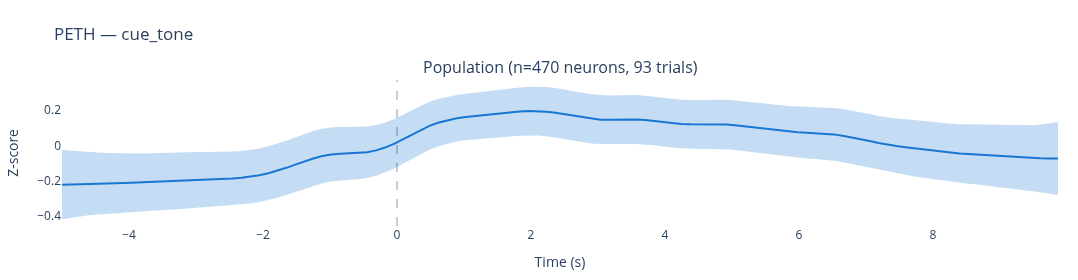

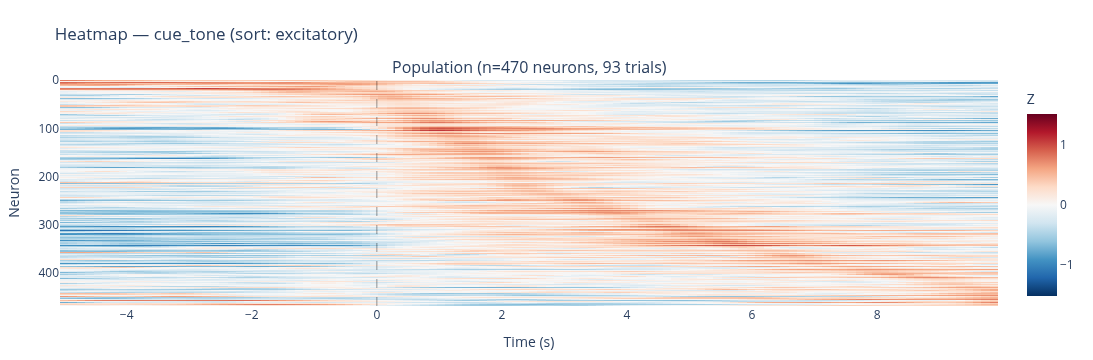

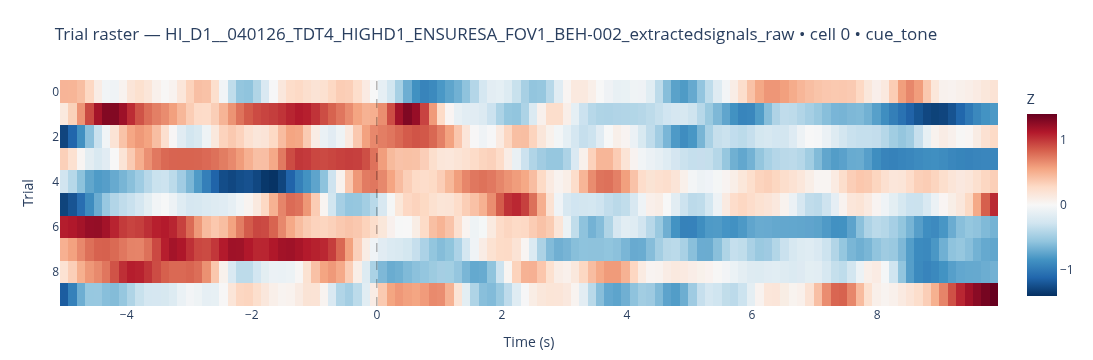

In [ ]:
# Pull current picker values, build the pipeline, compute, plot.
_v = _picker_values()
_eff_fps = next(iter(next(iter(SAMPLES_BY_GROUP.values())))).effective_fps if SAMPLES_BY_GROUP else FPS / FRAME_AVERAGING

_pipeline = build_default_pipeline(
    effective_fps=_eff_fps,
    dfof_pct=_v["dfof_pct"],
    zscore_window_ms=ZSCORE_WINDOW_MS,
    smoothing_sigma=_v["smoothing_sigma"],
    enable_dfof=_v["enable_dfof"],
    enable_zscore=_v["enable_zscore"],
    enable_smooth=_v["enable_smooth"],
)

_result = compute_for_view(
    SAMPLES_BY_GROUP,
    event_label=_v["event_label"],
    view_level=_v["view_level"],
    pre_s=_v["pre_s"],
    post_s=_v["post_s"],
    buffer_ms=_v["buffer_ms"],
    min_trials=MIN_TRIALS,
    pipeline=_pipeline,
    enable_zscore=_v["enable_zscore"],
)

print(f"Computed {len(_result['plots'])} plot(s) for '{_v['event_label']}' "
      f"at view='{_v['view_level']}'.")

plot_peth(_result).show()
plot_heatmap(_result, sort_method=_v["sort_method"], enable_zscore=_v["enable_zscore"]).show()

# Single-cell raster -- pick the first sample of the first group, cell 0.
if SAMPLES_BY_GROUP:
    _first_sample = next(iter(next(iter(SAMPLES_BY_GROUP.values()))))
    plot_trial_raster(
        _first_sample, _v["event_label"], cell_id=0,
        pre_s=_v["pre_s"], post_s=_v["post_s"], buffer_ms=_v["buffer_ms"],
        pipeline=_pipeline, enable_zscore=_v["enable_zscore"],
    ).show()
